In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy
import xarray as xr
from scipy.stats import kendalltau
import seaborn as sns
from scipy.stats.mstats import theilslopes
import geopandas as gpd

import pymannkendall as mk

In [2]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

colors = ['red','blue','green','yellow']
markers = ['o','d','p','^']


In [3]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'North North Island', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}

cluster_lists = {6:winter,9:spring,12:summer,3:autumn}
names_list = {6:winter_names,9:spring_names,12:summer_names,3:autumn_names}

In [4]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                           geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                           crs='EPSG:4326')


6
Northland: -0.01235974509071184, 0.03263005983871792
Central North Island: -0.005615286726985265, 0.25128128332079647
West South Island: 0.011678264005646463, 6.818755483006811e-05
East South Island: -0.0017951301458179341, 0.8300358809142383

9
East: -0.0056184806433354885, 0.19153604318885775
West: 0.0028718347966343555, 0.37335259968884094

12
Northland: -0.007686554666053339, 0.09543062528901824
South North Island: -0.002525948276524475, 0.6980597760556866
West South Island: -0.001962640161466872, 0.5445167411807605
East South Island: 0.0002910836328700782, 0.8959416363614563

3
North: -0.00722056396370339, 0.11421535165364727
South: -0.004518273464685282, 0.16747347146094094


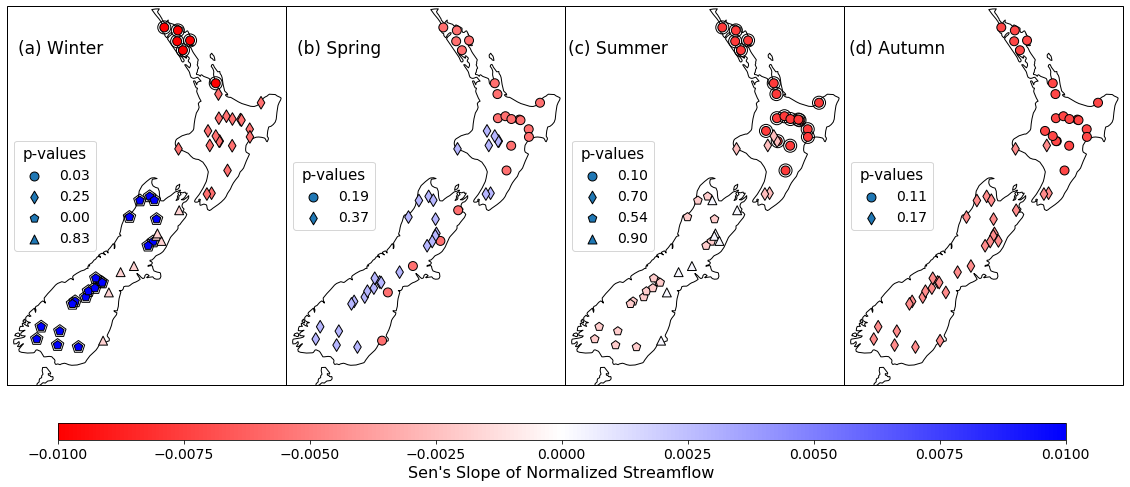

In [5]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()
alpha = ['a','b','c','d']
for i,s in enumerate(seasons_n):
    
    print('\n'+str(s))
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.19, .89, "(" + alpha[i] + ") " +seasons_a[i], fontsize= 17, horizontalalignment="center", 
                verticalalignment="center", transform=axs[i].transAxes)

    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_index = 0
        for j in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[j]))>2:
                multiple_records_index = j
                break

        cluster_df = cluster_df.iloc[multiple_records_index:]
        #cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()
        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        #averaged_cluster = (averaged_cluster - averaged_cluster.mean())/averaged_cluster.std()
        
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        #coef, p = kendalltau(years,vals,nan_policy='omit')
        trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(vals)
        
        lons = []
        lats = []
        sens = []
        for site in cluster_df:
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
        
            if p < 0.1:
                axs[i].scatter(lon,lat, marker=markers[c-1],facecolors='none', edgecolors='black',s=170,zorder=50)

            lons.append(lon)
            lats.append(lat)
            sens.append(slope)

        
        im = axs[i].scatter(lons,lats,c=sens, cmap='bwr_r',marker=markers[c-1],vmin=-0.01,vmax=0.01,s=80,
                            label="{:.2f}".format(p),zorder=100, edgecolor='black')# if p > 0.1 else 'limegreen'
        
        print(cluster_names[c] + ": " + str(slope) + ", " + str(p))


    axs[i].legend(loc='center left',title='p-values', title_fontsize=15, prop={'size': 14})
    
plt.subplots_adjust(wspace=0, hspace=0)

cax = fig.add_axes([0.16,0.22,.7,.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Sen\'s Slope of Normalized Streamflow',size=16)

plt.savefig('Figure6_sens.png',dpi=300,bbox_inches='tight')


In [5]:
'''
Make TABLE of regional trend results with maximum time window for each season / region.
'''

seasons = []
regions = []
time_windows = []
slopes = []
pvalues = []

for i,s in enumerate(seasons_n):

    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_index = 0
        for j in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[j]))>2:
                multiple_records_index = j
                break

        start_year = str(cluster_df.index[multiple_records_index].year)
        
        cluster_df = cluster_df.iloc[multiple_records_index:]
        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(vals)
        
        seasons.append(seasons_a[i])
        regions.append(cluster_names[c])
        time_windows.append(start_year + "-2019")
        slopes.append(slope)
        pvalues.append(p)
        

print(seasons)
print(regions)
print(time_windows)
print(slopes)
print(pvalues)


df = pd.DataFrame({'Season':seasons,'Region':regions,'Time Window':time_windows,'Sen\'s Slope':slopes,'P-value':pvalues})

df.to_csv("regional_results_table.csv")

['Winter', 'Winter', 'Winter', 'Winter', 'Spring', 'Spring', 'Summer', 'Summer', 'Summer', 'Summer', 'Autumn', 'Autumn']
['Northland', 'Central North Island', 'West South Island', 'East South Island', 'East', 'West', 'North North Island', 'South North Island', 'West South Island', 'East South Island', 'North', 'South']
['1960-2019', '1953-2019', '1932-2019', '1962-2019', '1954-2019', '1932-2019', '1952-2019', '1966-2019', '1931-2019', '1961-2019', '1955-2019', '1932-2019']
[-0.01235974509071184, -0.005615286726985265, 0.011678264005646463, -0.0017951301458179341, -0.0056184806433354885, 0.0028718347966343555, -0.007686554666053339, -0.002525948276524475, -0.001962640161466872, 0.0002910836328700782, -0.00722056396370339, -0.004518273464685282]
[0.03263005983871792, 0.25128128332079647, 6.818755483006811e-05, 0.8300358809142383, 0.19153604318885775, 0.37335259968884094, 0.09543062528901824, 0.6980597760556866, 0.5445167411807605, 0.8959416363614563, 0.11421535165364727, 0.16747347146094

In [10]:
df

,Season,Region,Time Window,Sen's Slope,P-value
0,Winter,Northland,1960-2019,-0.012360,0.032630
1,Winter,Central North Island,1953-2019,-0.005615,0.251281
2,Winter,West South Island,1932-2019,0.011678,0.000068
3,Winter,East South Island,1962-2019,-0.001795,0.830036
4,Spring,East,1954-2019,-0.005618,0.191536
5,Spring,West,1932-2019,0.002872,0.373353
6,Summer,Northland,1952-2019,-0.007687,0.095431
7,Summer,South North Island,1966-2019,-0.002526,0.698060
8,Summer,West South Island,1931-2019,-0.001963,0.544517
9,Summer,East South Island,1961-2019,0.000291,0.895942


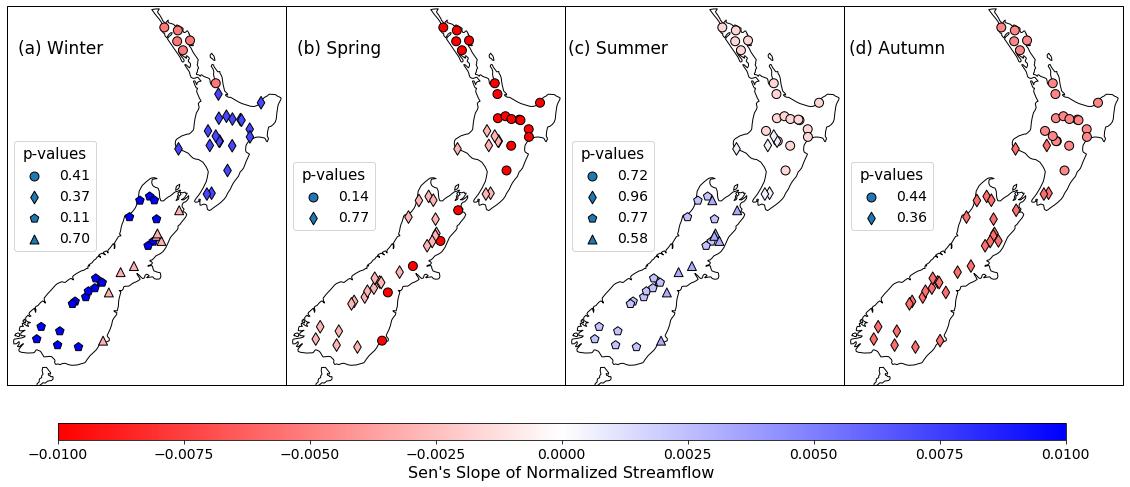

In [6]:
'''
Use SHARED 50-year window, 1969-2019.
'''

# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()
alpha = ['a','b','c','d']
for i,s in enumerate(seasons_n):
    
    #print('\n'+str(s))
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.19, .89, "(" + alpha[i] + ") " +seasons_a[i], fontsize= 17, horizontalalignment="center", 
                verticalalignment="center", transform=axs[i].transAxes)

    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        cluster_df = cluster_df['1969':'2019']

        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        #averaged_cluster = (averaged_cluster - averaged_cluster.mean())/averaged_cluster.std()
        
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        #coef, p = kendalltau(years,vals,nan_policy='omit')
        trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(vals)
        
        lons = []
        lats = []
        sens = []
        for site in cluster_df:
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
        
            if p < 0.1:
                axs[i].scatter(lon,lat, marker=markers[c-1],facecolors='none', edgecolors='black',s=170,zorder=50)

            lons.append(lon)
            lats.append(lat)
            sens.append(slope)

        
        im = axs[i].scatter(lons,lats,c=sens, cmap='bwr_r',marker=markers[c-1],vmin=-0.01,vmax=0.01,s=80,
                            label="{:.2f}".format(p),zorder=100, edgecolor='black')# if p > 0.1 else 'limegreen'
        
        #axs[i].text(0.45,0.1,"Shared Time Window:\n" + "1969-2019",transform=axs[i].transAxes, fontsize=14)

        #print(cluster_names[c] + ": " + str(slope) + ", " + str(p))


    axs[i].legend(loc='center left',title='p-values', title_fontsize=15, prop={'size': 14})
    
plt.subplots_adjust(wspace=0, hspace=0)

cax = fig.add_axes([0.16,0.22,.7,.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Sen\'s Slope of Normalized Streamflow',size=16)

plt.savefig('Figure6_sens_shared_window.png',dpi=300,bbox_inches='tight')


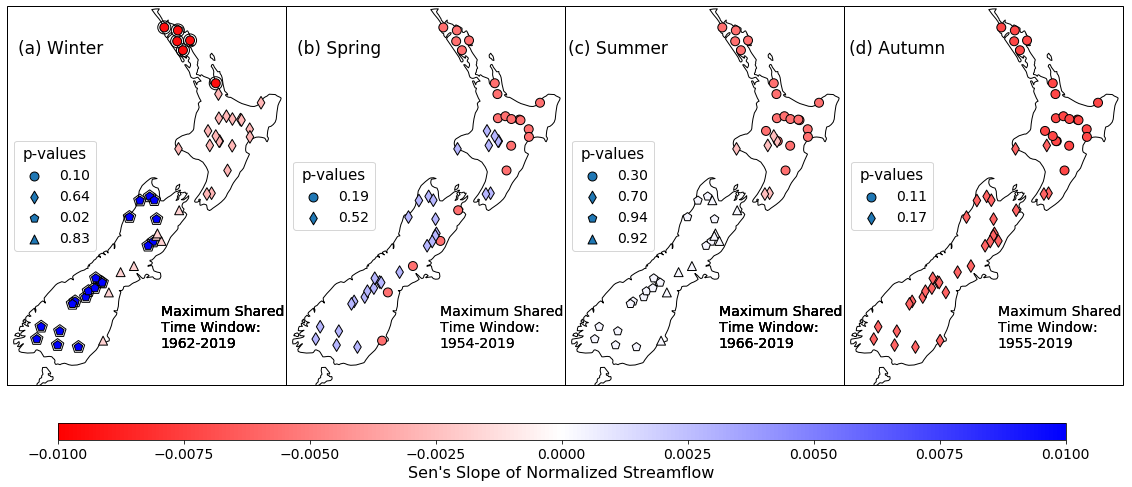

In [13]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

fig, axs = plt.subplots(1,4, subplot_kw={'projection': crs},figsize=(20,12))
axs = axs.flatten()
alpha = ['a','b','c','d']
for i,s in enumerate(seasons_n):
    
    #print('\n'+str(s))
    axs[i].coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
    axs[i].set_xlim([18500000,19900000])
    axs[i].set_ylim([-5950000,-4050000])
    axs[i].text(.19, .89, "(" + alpha[i] + ") " +seasons_a[i], fontsize= 17, horizontalalignment="center", 
                verticalalignment="center", transform=axs[i].transAxes)

    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]

    df = flow_df[flow_df.index.month.isin([s])]

    maximum_shared_window_start_index = 0
    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_index = 0
        for j in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[j]))>2:
                multiple_records_index = j
                break
        
        if multiple_records_index > maximum_shared_window_start_index:
            maximum_shared_window_start_index = multiple_records_index

    max_shared_window_start_year = str(cluster_df.index[maximum_shared_window_start_index].year)
    
    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        cluster_df = cluster_df.iloc[maximum_shared_window_start_index:]

        cluster_df = (cluster_df - cluster_df.mean())/cluster_df.std()
        
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        #averaged_cluster = (averaged_cluster - averaged_cluster.mean())/averaged_cluster.std()
        
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        #coef, p = kendalltau(years,vals,nan_policy='omit')
        trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(vals)
        
        lons = []
        lats = []
        sens = []
        for site in cluster_df:
            lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
            lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]
        
            if p < 0.1:
                axs[i].scatter(lon,lat, marker=markers[c-1],facecolors='none', edgecolors='black',s=170,zorder=50)

            lons.append(lon)
            lats.append(lat)
            sens.append(slope)

        
        im = axs[i].scatter(lons,lats,c=sens, cmap='bwr_r',marker=markers[c-1],vmin=-0.01,vmax=0.01,s=80,
                            label="{:.2f}".format(p),zorder=100, edgecolor='black')# if p > 0.1 else 'limegreen'
        
        axs[i].text(0.55,0.1,"Maximum Shared \nTime Window:\n" + max_shared_window_start_year + "-2019",transform=axs[i].transAxes, fontsize=14)
        #print(cluster_names[c] + ": " + str(slope) + ", " + str(p))


    axs[i].legend(loc='center left',title='p-values', title_fontsize=15, prop={'size': 14})
    
plt.subplots_adjust(wspace=0, hspace=0)

cax = fig.add_axes([0.16,0.22,.7,.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Sen\'s Slope of Normalized Streamflow',size=16)

#plt.savefig('Figure6_sens.png',dpi=300,bbox_inches='tight')
